# Ứng dụng 2 — Dự đoán giá nhà Hà Nội

**Quy trình:** Data → Understand → Clean → Represent → Train → Validate → Test → Persist → Deploy

## 1. Bài toán và nguồn dữ liệu

- **Dataset:** Vietnam Housing Dataset (Hà Nội) — https://www.kaggle.com/code/kerneler/starter-vietnam-housing-dataset-5742ed64-7/input
- **Mục tiêu:** hồi quy giá bán nhà Hà Nội theo đơn vị tỷ VNĐ.
- **Một quan sát:** một tin đăng bất động sản.
- **Đặc trưng triển khai:** diện tích, số phòng ngủ, số tầng, quận, loại hình nhà, tình trạng pháp lý.
- `Giá/m2` chỉ dùng để tạo nhãn `Price`, sau đó bị loại khỏi X để ngăn target leakage.

Notebook dùng validation để so sánh 5 mô hình; test chỉ được dùng một lần sau lựa chọn.

In [1]:
from pathlib import Path
import json, os, re, warnings
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-asg02")
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
ROOT = Path.cwd()
(ROOT / "models").mkdir(exist_ok=True)
(ROOT / "artifacts").mkdir(exist_ok=True)
(ROOT / "figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GroupShuffleSplit

## 2. Kiểm tra dữ liệu bắt buộc

In [2]:
df_raw = pd.read_csv(ROOT / "VN_housing_dataset.csv")
print("shape:", df_raw.shape)
display(df_raw.head().T)
df_raw.info()
display(df_raw.describe(include="number").T[["count", "mean", "std", "min", "50%", "max"]].round(2))
display(df_raw.describe(exclude="number").T[["count", "unique", "top", "freq"]])
print("\nMissing values:\n", df_raw.isna().sum())
print("\nDuplicated records:", df_raw.duplicated().sum())

shape: (82497, 13)


,0,1,2,3,4
Unnamed: 0,0.0,1.0,2.0,3.0,4.0
Ngày,2020-08-05,2020-08-05,2020-08-05,2020-08-05,2020-08-05
Địa chỉ,"Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận C...","Đường Kim Giang, Phường Kim Giang, Quận Thanh ...","phố minh khai, Phường Minh Khai, Quận Hai Bà T...","Đường Võng Thị, Phường Thụy Khuê, Quận Tây Hồ,...","Đường Kim Giang, Phường Kim Giang, Quận Thanh ..."
Quận,Quận Cầu Giấy,Quận Thanh Xuân,Quận Hai Bà Trưng,Quận Tây Hồ,Quận Thanh Xuân
Huyện,Phường Nghĩa Đô,Phường Kim Giang,Phường Minh Khai,Phường Thụy Khuê,Phường Kim Giang
Loại hình nhà ở,"Nhà ngõ, hẻm","Nhà mặt phố, mặt tiền","Nhà ngõ, hẻm","Nhà ngõ, hẻm","Nhà ngõ, hẻm"
Giấy tờ pháp lý,Đã có sổ,NaN,Đã có sổ,Đã có sổ,NaN
Số tầng,4,NaN,4,NaN,NaN
Số phòng ngủ,5 phòng,3 phòng,4 phòng,6 phòng,4 phòng
Diện tích,46 m²,37 m²,40 m²,51 m²,36 m²


<class 'pandas.DataFrame'>
RangeIndex: 82497 entries, 0 to 82496
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       82496 non-null  float64
 1   Ngày             82496 non-null  str    
 2   Địa chỉ          82449 non-null  str    
 3   Quận             82495 non-null  str    
 4   Huyện            82449 non-null  str    
 5   Loại hình nhà ở  82465 non-null  str    
 6   Giấy tờ pháp lý  53610 non-null  str    
 7   Số tầng          36399 non-null  str    
 8   Số phòng ngủ     82458 non-null  str    
 9   Diện tích        82495 non-null  str    
 10  Dài              19827 non-null  str    
 11  Rộng             35445 non-null  str    
 12  Giá/m2           82484 non-null  str    
dtypes: float64(1), str(12)
memory usage: 8.2 MB


,count,mean,std,min,50%,max
Unnamed: 0,82496.0,41247.5,23814.69,0.0,41247.5,82495.0


,count,unique,top,freq
Ngày,82496,174,2020-08-04,2616
Địa chỉ,82449,13957,"Đường Minh Khai, Phường Minh Khai, Quận Hai Bà...",1266
Quận,82495,29,Quận Đống Đa,13991
Huyện,82449,309,Phường Khương Trung,2832
Loại hình nhà ở,82465,4,"Nhà ngõ, hẻm",62537
Giấy tờ pháp lý,53610,3,Đã có sổ,52914
Số tầng,36399,29,5,15770
Số phòng ngủ,82458,11,4 phòng,29069
Diện tích,82495,504,40 m²,6606
Dài,19827,487,10 m,3912



Missing values:
 Unnamed: 0             1
Ngày                   1
Địa chỉ               48
Quận                   2
Huyện                 48
Loại hình nhà ở       32
Giấy tờ pháp lý    28887
Số tầng            46098
Số phòng ngủ          39
Diện tích              2
Dài                62670
Rộng               47052
Giá/m2                13
dtype: int64

Duplicated records: 0


## 3. Làm sạch có quy tắc nghiệp vụ

Dữ liệu Việt Nam dùng dấu phẩy thập phân và ba đơn vị `triệu/m²`, `tỷ/m²`, `đ/m²`. Hàm dưới đây quy đổi tất cả về **triệu VNĐ/m²** trước khi tính `Price`. Các ngưỡng cố định (không học từ test) loại bản ghi không thể tin cậy: diện tích 10–1000 m², đơn giá 0.1–1000 triệu/m², tổng giá 0.1–300 tỷ. Không gọi đây là IQR vì ngưỡng là quy tắc nghiệp vụ.

In [3]:
def first_decimal(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"\d+(?:[\.,]\d+)?", str(value))
    return float(match.group(0).replace(",", ".")) if match else np.nan

def price_per_m2_to_million(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower().strip()
    match = re.search(r"\d+(?:[\.,]\d+)?", text)
    if not match:
        return np.nan
    token = match.group(0)
    if "triệu" in text:
        return float(token.replace(",", "."))
    if "tỷ" in text:
        return float(token.replace(",", ".")) * 1000.0
    # Chuỗi dạng 90.476 đ/m² dùng dấu chấm phân cách hàng nghìn.
    return float(token.replace(".", "")) / 1_000_000.0

df = df_raw.copy()
df["Diện tích"] = df["Diện tích"].map(first_decimal)
df["Số phòng ngủ"] = df["Số phòng ngủ"].map(first_decimal)
df["Số tầng"] = df["Số tầng"].map(first_decimal)
df["Đơn giá (triệu/m²)"] = df["Giá/m2"].map(price_per_m2_to_million)
df["Price"] = df["Diện tích"] * df["Đơn giá (triệu/m²)"] / 1000.0

features = ["Diện tích", "Số phòng ngủ", "Số tầng", "Quận", "Loại hình nhà ở", "Giấy tờ pháp lý"]
target = "Price"
valid = (
    df["Diện tích"].between(10, 1000)
    & df["Đơn giá (triệu/m²)"].between(0.1, 1000)
    & df["Price"].between(0.1, 300)
)
df = df.loc[valid, features + [target]].copy()
for col in ["Quận", "Loại hình nhà ở", "Giấy tờ pháp lý"]:
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Valid rows before/after exact de-duplication: {before:,} / {len(df):,}")
display(df.head())

Valid rows before/after exact de-duplication: 81,513 / 63,021


,Diện tích,Số phòng ngủ,Số tầng,Quận,Loại hình nhà ở,Giấy tờ pháp lý,Price
0,46.0,5.0,4.0,Quận Cầu Giấy,"Nhà ngõ, hẻm",Đã có sổ,4.00016
1,37.0,3.0,NaN,Quận Thanh Xuân,"Nhà mặt phố, mặt tiền",Unknown,4.30014
2,40.0,4.0,4.0,Quận Hai Bà Trưng,"Nhà ngõ, hẻm",Đã có sổ,2.60000
3,51.0,6.0,NaN,Quận Tây Hồ,"Nhà ngõ, hẻm",Đã có sổ,5.10000
4,36.0,4.0,NaN,Quận Thanh Xuân,"Nhà ngõ, hẻm",Unknown,3.09996


## 4. Chia 70/15/15 theo nhóm đặc trưng

Vì nhiều tin có cùng sáu đặc trưng triển khai, `GroupShuffleSplit` giữ toàn bộ hồ sơ có cùng vector X trong cùng một tập. Nhờ vậy test không chứa bản sao chính xác của một profile đã thấy ở train. Imputer/encoder/scaler vẫn chỉ fit trên train.

In [4]:
X, y = df[features], df[target]
group_key = X.astype("string").fillna("<NA>").agg("|".join, axis=1)
outer = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=RANDOM_STATE)
train_idx, temp_idx = next(outer.split(X, y, groups=group_key))
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
temp_groups = group_key.iloc[temp_idx]
inner = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=RANDOM_STATE)
val_rel, test_rel = next(inner.split(X_temp, y_temp, groups=temp_groups))
X_val, y_val = X_temp.iloc[val_rel], y_temp.iloc[val_rel]
X_test, y_test = X_temp.iloc[test_rel], y_temp.iloc[test_rel]

def keys(frame):
    return set(frame.astype("string").fillna("<NA>").agg("|".join, axis=1))
print("train/validation/test:", X_train.shape, X_val.shape, X_test.shape)
print("Exact profile overlap train-test:", len(keys(X_train) & keys(X_test)))

train/validation/test: (44644, 6) (9084, 6) (9293, 6)
Exact profile overlap train-test: 0


## 5. EDA: quan sát → diễn giải → hàm ý ML

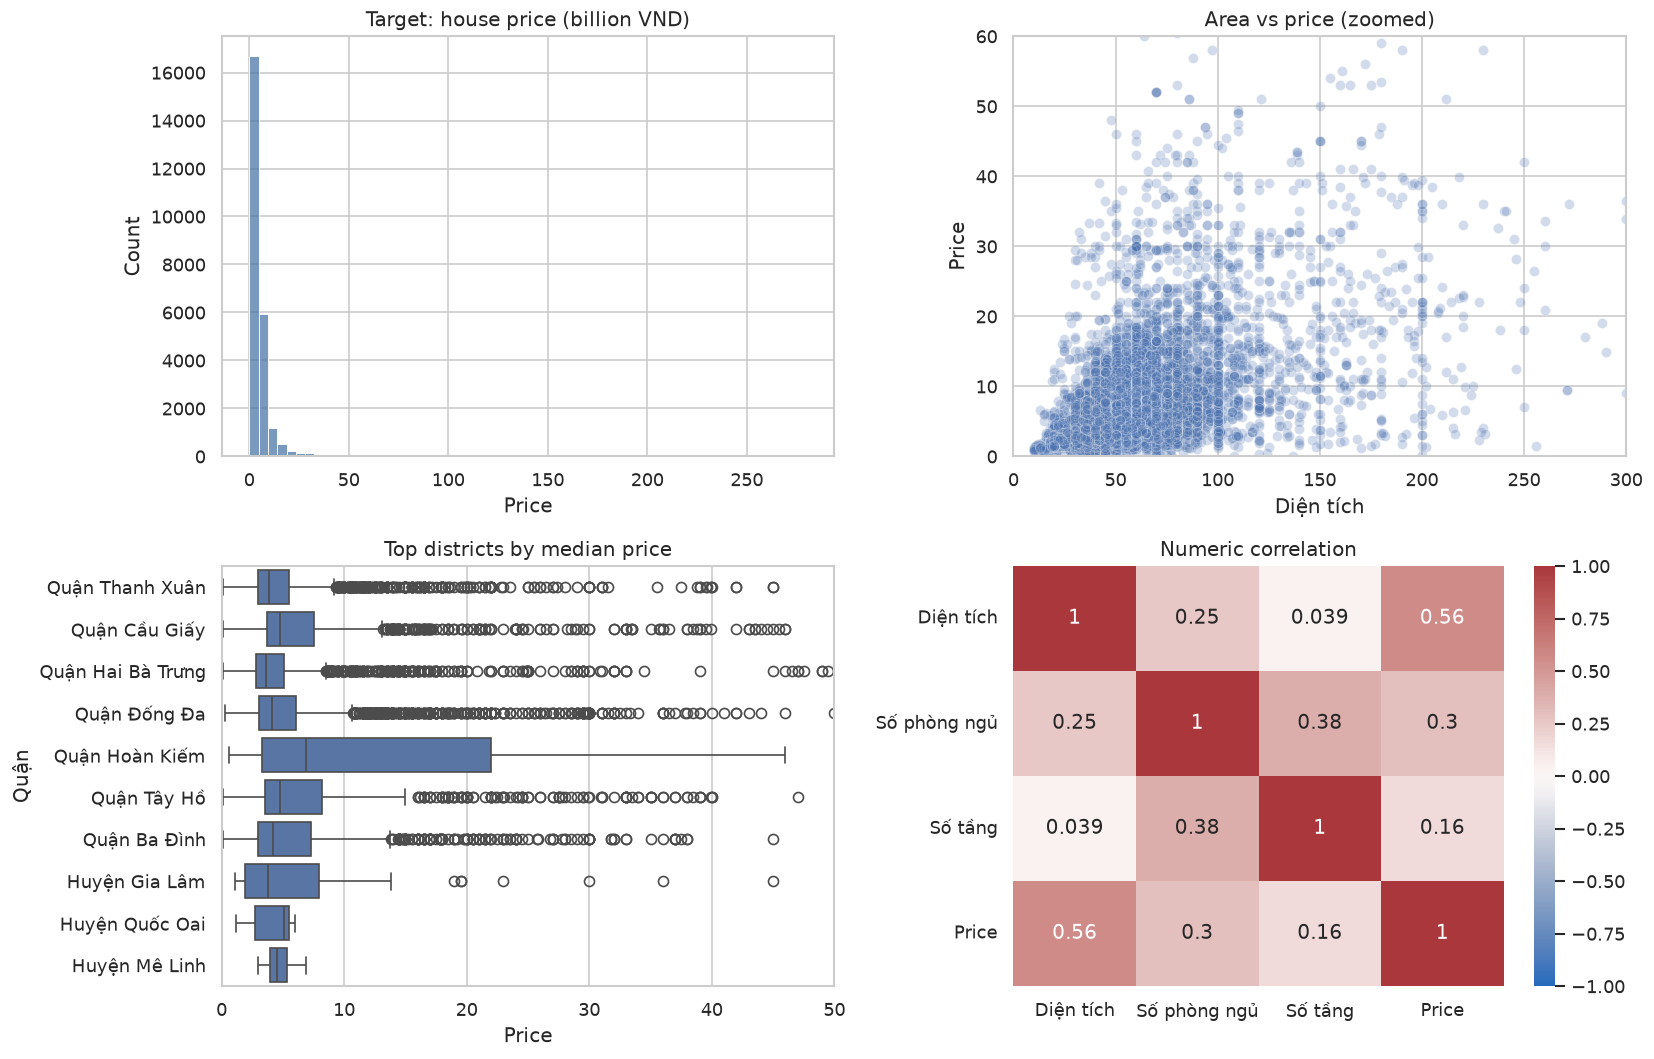

Observation: giá lệch phải; diện tích và quận liên quan rõ đến giá.
Interpretation: một số giao dịch cao giá vẫn còn hợp lệ sau lọc nghiệp vụ.
ML implication: ưu tiên MAE, đồng thời báo RMSE để phạt sai số lớn.


In [5]:
sample = df.sample(min(25000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(sample["Price"], bins=60, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Target: house price (billion VND)")
sns.scatterplot(data=sample, x="Diện tích", y="Price", alpha=.25, ax=axes[0, 1])
axes[0, 1].set_xlim(0, 300); axes[0, 1].set_ylim(0, 60)
axes[0, 1].set_title("Area vs price (zoomed)")
district_order = sample.groupby("Quận")["Price"].median().nlargest(10).index
sns.boxplot(data=sample[sample["Quận"].isin(district_order)], y="Quận", x="Price", ax=axes[1, 0])
axes[1, 0].set_xlim(0, 50); axes[1, 0].set_title("Top districts by median price")
sns.heatmap(df[["Diện tích", "Số phòng ngủ", "Số tầng", "Price"]].corr(), annot=True, cmap="vlag", vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title("Numeric correlation")
plt.tight_layout()
plt.savefig(ROOT / "figures/housing_eda.png", dpi=160, bbox_inches="tight")
plt.show()

print("Observation: giá lệch phải; diện tích và quận liên quan rõ đến giá.")
print("Interpretation: một số giao dịch cao giá vẫn còn hợp lệ sau lọc nghiệp vụ.")
print("ML implication: ưu tiên MAE, đồng thời báo RMSE để phạt sai số lớn.")

## 6. Biểu diễn dữ liệu

Ba biến số được điền trung vị và chuẩn hóa; ba biến phân loại được điền `Unknown` rồi one-hot. Vector cuối có $d$ chiều, batch có dạng $B	imes d$.

In [6]:
numeric_features = ["Diện tích", "Số phòng ngủ", "Số tầng"]
categorical_features = ["Quận", "Loại hình nhà ở", "Giấy tờ pháp lý"]
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])
representation = clone(preprocessor).fit_transform(X_train)
display(X_train.head(1))
print("Raw matrix:", X_train.shape)
print("Final numerical matrix:", representation.shape, representation.dtype)
print("One vector (rounded):", np.round(representation[0], 3))

,Diện tích,Số phòng ngủ,Số tầng,Quận,Loại hình nhà ở,Giấy tờ pháp lý
3,51.0,6.0,NaN,Quận Tây Hồ,"Nhà ngõ, hẻm",Đã có sổ


Raw matrix: (44644, 6)
Final numerical matrix: (44644, 42) float64
One vector (rounded): [0.058 1.337 0.23  0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    1.
 0.    0.    0.    0.    0.    1.   ]


## 7. So sánh 5 mô hình trên validation

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=16, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, min_samples_leaf=2, max_features=.8, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=180, learning_rate=.07, l2_regularization=1.0, random_state=RANDOM_STATE),
}

def score_regression(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    mse = mean_squared_error(y_eval, pred)
    return {"MAE": mean_absolute_error(y_eval, pred), "MSE": mse, "RMSE": np.sqrt(mse), "R2": r2_score(y_eval, pred)}

rows = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    pipe.fit(X_train, y_train)
    rows.append({"Model": name, **score_regression(pipe, X_val, y_val)})
comparison = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
display(comparison.style.format({"MAE":"{:.4f}", "MSE":"{:.4f}", "RMSE":"{:.4f}", "R2":"{:.4f}"}))
comparison.to_csv(ROOT / "artifacts/housing_validation_metrics.csv", index=False)
selected_name = comparison.loc[0, "Model"]
print("Selected by validation MAE:", selected_name)

# Khoảng bất định vận hành: bách phân vị 90% của |residual| trên validation.
# Đây là heuristic được hiệu chỉnh trên validation, không phải confidence interval thống kê.
interval_pipeline = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(models[selected_name]))])
interval_pipeline.fit(X_train, y_train)
validation_abs_error_q90 = float(np.quantile(np.abs(y_val.to_numpy() - interval_pipeline.predict(X_val)), 0.90))
print("Validation absolute-error q90 (billion VND):", round(validation_abs_error_q90, 4))

,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,1.7787,22.4811,4.7414,0.6127
1,Random Forest,1.8020,21.8639,4.6759,0.6234
2,Decision Tree,1.9648,27.9912,5.2907,0.5178
3,Ridge,2.3000,33.2300,5.7645,0.4276
4,Linear Regression,2.3039,33.1110,5.7542,0.4296


Selected by validation MAE: Gradient Boosting
Validation absolute-error q90 (billion VND): 3.595


## 8. Refit train+validation, test đúng một lần và lưu pipeline

FINAL TEST METRICS


,MAE,MSE,RMSE,R2
0,1.8184,26.5091,5.1487,0.5174


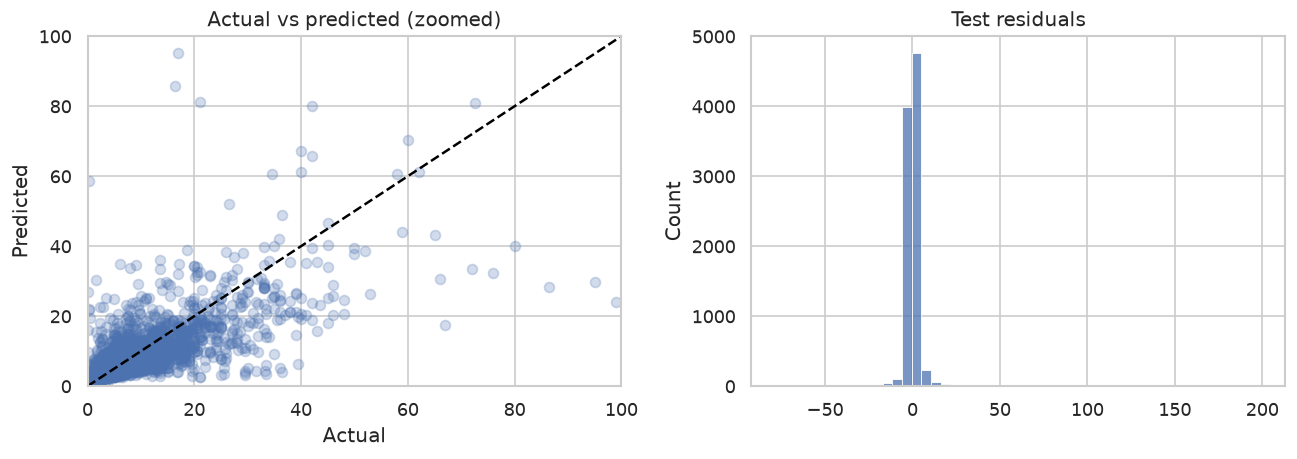

Saved models/housing_pipeline.joblib and metadata.


In [8]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
final_pipeline = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(models[selected_name]))])
final_pipeline.fit(X_trainval, y_trainval)
test_metrics = score_regression(final_pipeline, X_test, y_test)
print("FINAL TEST METRICS")
display(pd.DataFrame([test_metrics]).style.format("{:.4f}"))

test_pred = final_pipeline.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, test_pred, alpha=.25)
lims = [0, min(100, max(float(y_test.max()), float(test_pred.max())))]
axes[0].plot(lims, lims, "--", color="black"); axes[0].set(xlim=lims, ylim=lims, xlabel="Actual", ylabel="Predicted", title="Actual vs predicted (zoomed)")
residual = y_test.to_numpy() - test_pred
sns.histplot(residual, bins=50, ax=axes[1]); axes[1].set_title("Test residuals")
plt.tight_layout()
plt.savefig(ROOT / "figures/housing_test_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()

joblib.dump(final_pipeline, ROOT / "models/housing_pipeline.joblib", compress=3)
metadata = {
    "application": "housing", "selected_model": selected_name, "raw_features": features,
    "target_unit": "billion VND", "split": "group-aware approx. 70/15/15; selection on validation; one final test evaluation",
    "selection_metric": "MAE", "test_metrics": test_metrics,
    "validation_absolute_error_q90": validation_abs_error_q90,
    "uncertainty_note": "Heuristic prediction range based on validation absolute-error q90; not a statistical confidence interval",
    "final_input_shape": [int(len(X_trainval)), int(final_pipeline.named_steps["preprocess"].transform(X_trainval.head(1)).shape[1])],
    "random_state": RANDOM_STATE,
}
(ROOT / "models/housing_metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved models/housing_pipeline.joblib and metadata.")